# Author: Geshna Garga
# Project: Customer Segmentation

In [1]:
import pandas as pd

rfm = pd.read_csv(r"C:\Users\Geshna\OneDrive\Projects\Customer Segmentation\data\processed\rfm.csv", index_col=0)

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

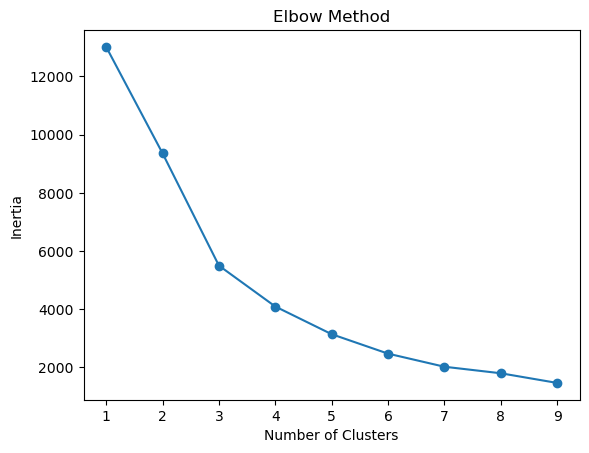

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [9]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [11]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [13]:
def label_cluster(cluster):
    if cluster == 2:
        return "High Value"
    elif cluster == 3:
        return "Loyal Customers"
    elif cluster == 0:
        return "Potential Customers"
    else:
        return "At Risk Customers"

rfm['Segment'] = rfm['Cluster'].apply(label_cluster)

In [15]:
rfm[['Cluster', 'Segment']].head()
rfm['Segment'].value_counts()

Segment
Potential Customers    3054
At Risk Customers      1067
Loyal Customers         204
High Value               13
Name: count, dtype: int64

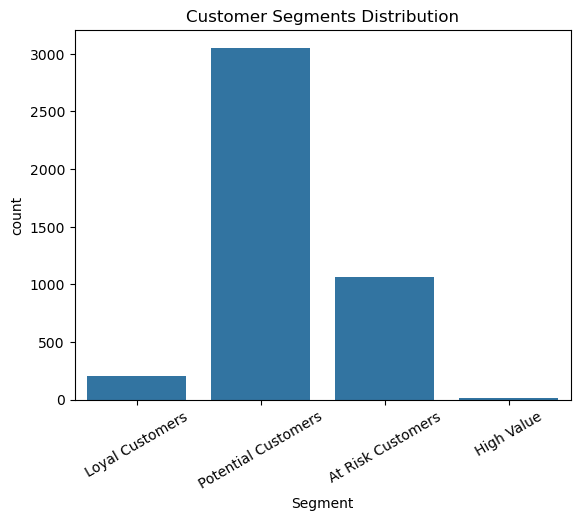

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=30)
plt.title("Customer Segments Distribution")
plt.show()

Customers were segmented into four distinct groups based on RFM behavior. 
High-value customers contribute significantly to revenue, while at-risk customers show low engagement and require reactivation strategies.

### 🟢 High Value Customers

Profile:

Recent purchases
Very high frequency
Extremely high spending

Strategy:

Provide exclusive loyalty rewards and VIP benefits
Offer early access to new products
Maintain engagement through personalized communication

Goal: retain + maximize lifetime value


### 🔵 Loyal Customers

Profile:

Regular buyers
High engagement
Good spending

Strategy:

Upsell premium products
Introduce bundled offers
Reward consistency with loyalty programs

Goal: increase average order value


### 🟡 Potential Customers

Profile:

Moderate activity
Inconsistent purchasing behavior

Strategy:

Target with personalized offers
Provide incentives for repeat purchases
Use email campaigns to increase engagement

Goal: convert into loyal customers


### 🔴 At Risk Customers

Profile:

Long time since last purchase
Low frequency
Low spending

Strategy:

Launch reactivation campaigns (discounts, offers)
Send reminder emails or notifications
Identify reasons for disengagement

Goal: win back before churn

Segment-based marketing enables businesses to allocate resources efficiently and maximize ROI by targeting customers based on their behavior and value.